<a href="https://colab.research.google.com/github/xofranc/conversationalBI/blob/main/playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de fraude en seguros de vehículos
   El fraude en seguros de vehículos implica conspirar para presentar reclamaciones falsas o exageradas por daños materiales o lesiones personales tras un accidente. Algunos ejemplos comunes incluyen accidentes simulados, donde los estafadores "organizan" deliberadamente accidentes; el uso de pasajeros ficticios, donde personas que ni siquiera estaban en el lugar del accidente afirman haber sufrido lesiones graves; y reclamaciones falsas por lesiones personales, donde las lesiones se exageran considerablemente.

## Acerca de este conjunto de datos
   Este conjunto de datos contiene información sobre vehículos (atributos, modelo, detalles del accidente, etc.) junto con detalles de la póliza (tipo de póliza, duración, etc.). El objetivo es detectar si una solicitud de reclamación es fraudulenta o no (FraudFound_P).

| Columna              | dtype pandas | Tipo Analítico         | Tratamiento Recomendado            |
| -------------------- | ------------ | ---------------------- | ---------------------------------- |
| Month                | object       | Temporal cíclica       | Map 1-12 o Sin/Cos                 |
| WeekOfMonth          | int64        | Discreta ordinal       | Mantener numérica                  |
| DayOfWeek            | object       | Temporal cíclica       | Map 1-7 o Sin/Cos                  |
| Make                 | object       | Nominal                | One-Hot / Frequency Encoding       |
| AccidentArea         | object       | Binaria                | Map 0/1                            |
| DayOfWeekClaimed     | object       | Temporal cíclica       | Map 1-7 o Sin/Cos                  |
| MonthClaimed         | object       | Temporal cíclica       | Map 1-12 o Sin/Cos                 |
| WeekOfMonthClaimed   | int64        | Discreta ordinal       | Mantener numérica                  |
| Sex                  | object       | Binaria                | Map 0/1                            |
| MaritalStatus        | object       | Nominal                | One-Hot                            |
| Age                  | int64        | Numérica               | Mantener / revisar outliers        |
| Fault                | object       | Binaria                | Map 0/1                            |
| PolicyType           | object       | Compuesta / redundante | Evaluar eliminar                   |
| VehicleCategory      | object       | Nominal                | One-Hot                            |
| VehiclePrice         | object       | Ordinal                | Map ordenado                       |
| FraudFound_P         | int64        | Target                 | No transformar                     |
| PolicyNumber         | int64        | ID único               | Eliminar                           |
| RepNumber            | int64        | ID operativo           | Evaluar Frequency Encoding         |
| Deductible           | int64        | Numérica               | Mantener                           |
| DriverRating         | int64        | Ordinal                | Mantener / revisar escala          |
| Days_Policy_Accident | object       | Ordinal                | Map ordenado                       |
| Days_Policy_Claim    | object       | Ordinal                | Map ordenado                       |
| PastNumberOfClaims   | object       | Ordinal                | Map ordenado                       |
| AgeOfVehicle         | object       | Ordinal                | Map ordenado                       |
| AgeOfPolicyHolder    | object       | Ordinal                | Evaluar transformación o exclusión |
| PoliceReportFiled    | object       | Binaria                | Map 0/1                            |
| WitnessPresent       | object       | Binaria                | Map 0/1                            |
| AgentType            | object       | Binaria                | Map 0/1                            |
| NumberOfSuppliments  | object       | Ordinal                | Map ordenado                       |
| AddressChange_Claim  | object       | Ordinal                | Map ordenado                       |
| NumberOfCars         | object       | Ordinal                | Map ordenado                       |
| Year                 | int64        | Temporal numérica      | Mantener / revisar utilidad        |
| BasePolicy           | object       | Nominal                | One-Hot                            |

In [795]:
from doctest import DocFileCase
from pandas.core.interchange import column

# Instalacion de las librerias necesarias en el entorno local

In [796]:
import pandas as pd
import numpy as np

In [797]:
df = pd.read_csv('/content/fraud_oracle.csv')

df

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,35,Policy Holder,Sedan - Collision,Sedan,20000 to 29000,1,15416,5,400,4,more than 30,more than 30,2 to 4,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,30,Policy Holder,Sedan - Liability,Sport,30000 to 39000,0,15417,11,400,3,more than 30,more than 30,more than 4,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,24,Policy Holder,Sedan - Collision,Sedan,20000 to 29000,1,15418,4,400,4,more than 30,more than 30,more than 4,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,34,Third Party,Sedan - All Perils,Sedan,20000 to 29000,0,15419,6,400,4,more than 30,more than 30,none,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


In [798]:
df.dtypes

,0
Month,object
WeekOfMonth,int64
DayOfWeek,object
Make,object
AccidentArea,object
DayOfWeekClaimed,object
MonthClaimed,object
WeekOfMonthClaimed,int64
Sex,object
MaritalStatus,object


In [799]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [800]:
(df.isnull().sum() / len(df)) * 100

,0
Month,0.0
WeekOfMonth,0.0
DayOfWeek,0.0
Make,0.0
AccidentArea,0.0
DayOfWeekClaimed,0.0
MonthClaimed,0.0
WeekOfMonthClaimed,0.0
Sex,0.0
MaritalStatus,0.0


In [801]:
df.isna().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


# Teniendo en cuenta que no hay datos nulos, procedemos a la codificacion binaria de los datos, e identificacion de patrones anomalos para empezar a trabajar sobre ellos

## Primero revisamos que todos los datos no esten repetidos, para evitar sesgo en el modelo de clasificacion

In [802]:
df.duplicated().sum()

np.int64(0)

In [803]:
df.duplicated(['PolicyNumber']).sum()

np.int64(0)

## PolocyNumber es un identificador, por lo que no resulta relevante, porque no aporta informacion predictiva.

In [804]:
df.drop(columns=['PolicyNumber'], inplace=True)

## Tambien se tiene en cuenta que se realiza el filtro de la edad hasta 15 anos suponiendo que las licencias de conduccion son otorgadas en este pais desde los 16, por lo que no se presentan datos desde 15 para atras, ademas el 0 se presenta en 320 columnas lo que significa un 2.1% del dataset

In [805]:
df[df['Age'] <= 15]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,0,Policy Holder,Sport - Collision,Sport,more than 69000,0,1,400,4,more than 30,more than 30,1,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
13,Jan,5,Friday,Honda,Rural,Wednesday,Feb,1,Male,Single,0,Third Party,Sedan - Collision,Sedan,more than 69000,0,12,400,3,more than 30,more than 30,none,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
28,Jul,1,Saturday,Honda,Urban,Tuesday,Sep,4,Male,Single,0,Policy Holder,Sedan - All Perils,Sedan,more than 69000,1,9,400,1,more than 30,more than 30,none,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils
31,Mar,1,Sunday,Honda,Urban,Tuesday,Mar,2,Male,Single,0,Policy Holder,Sedan - Collision,Sedan,more than 69000,0,6,400,1,more than 30,more than 30,1,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
58,May,1,Monday,Honda,Rural,Wednesday,May,4,Male,Single,0,Policy Holder,Sedan - Liability,Sport,more than 69000,0,15,400,4,more than 30,more than 30,none,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Liability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15243,May,2,Tuesday,Honda,Urban,Monday,May,3,Male,Single,0,Policy Holder,Sedan - Liability,Sport,more than 69000,0,7,400,3,more than 30,more than 30,none,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability
15262,Mar,3,Monday,Honda,Urban,Thursday,Mar,3,Male,Single,0,Policy Holder,Sedan - Liability,Sport,more than 69000,0,5,400,3,more than 30,more than 30,more than 4,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability
15274,Apr,3,Monday,Honda,Urban,Tuesday,May,1,Male,Single,0,Third Party,Sedan - Collision,Sedan,more than 69000,0,1,400,2,more than 30,more than 30,more than 4,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Collision
15379,Jan,2,Tuesday,Honda,Urban,Thursday,Jan,2,Male,Single,0,Policy Holder,Utility - All Perils,Utility,more than 69000,0,1,400,3,more than 30,more than 30,more than 4,new,16 to 17,No,No,External,none,1 year,1 vehicle,1996,All Perils


In [806]:
df['AgeOfPolicyHolder'].unique()


array(['26 to 30', '31 to 35', '41 to 50', '51 to 65', '21 to 25',
       '36 to 40', '16 to 17', 'over 65', '18 to 20'], dtype=object)

## Identificamos los datos de las personas que tienen la póliza y los rangos de edad, para esclarecer los datos que tenemos en 0 en la columna Age, donde podemos darnos de cuenta, que la mayoria de los datos que estan en cero corresponden a menores de edad, que tienen la poliza a su nombre, entonces procedemos a una imputacion para poner el rango de edad en 16, con la informacion que tenemos de AgePolicyNumber

In [807]:
df.loc[df['Age'] == 0, 'Age'] = 16

### Analizando la base de datos se pueden deducir columnas con redundancia, como lo es PolicyType, esto podemos confirmarlo, con otras dos categorias, como lo es VehiculeCategory y BasePolicy, se procede a eliminar.

In [808]:
df = df.drop(columns=['PolicyType'])

In [809]:
df = df.drop(columns=['AgeOfPolicyHolder'])


# porque se tomo esta decision?

```python
import re


def rango_a_mid(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if "over" in x:
        nums = re.findall(r'\d+', x)
        if nums:
            return int(nums[0]) + 5
        return np.nan
    nums = re.findall(r'\d+', x)
    if len(nums) == 2:
        return (int(nums[0]) + int(nums[1])) / 2
    return np.nan

df["AgeHolder_num"] = df["AgeOfPolicyHolder"].apply(rango_a_mid)
df["age_gap"] = df["Age"] - df["AgeHolder_num"]

```
##### En un principio de agrego este fragmento de codigo con el fin de que poder poner un punto intermedio entre los Holders de las Polizas, pero, al crear la columna Age_gap se observa:
    * que hay incosistencias, porque la variable figura en rangos, y presenta informacion similar a Age
    * se evaluo su uso, pero se descarta por perdida de granulidad, y dificultad interpretativa.

estas razones reeplantearon la idea de no incluir el codigo porque produciria ruido al modelo

In [810]:
df = df.drop(columns=['Deductible', 'Year', 'AgentType', 'MonthClaimed', 'WeekOfMonthClaimed', 'DayOfWeekClaimed'])

## Borramos estas columnas por que tienen poca informacion util, ademas tratarlos representa patrones dificiles de defender, lo mismo que sucede con el Holder, por eso se toma esta decision

In [811]:
binarizacion = {
    'Sex': {"Female": 1, "Male": 0},
    'WitnessPresent': {"Yes": 1, "No": 0},
    'AccidentArea': {"Urban": 1, "Rural": 0},
    'PoliceReportFiled': {"Yes": 1, "No": 0},
    'Fault': {'Policy Holder': 1, 'Third Party': 0}
}

for col, mapa in binarizacion.items():
    df[col] = df[col].map(mapa)

In [812]:
df

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,BasePolicy
0,Dec,5,Wednesday,Honda,1,1,Single,21,1,Sport,more than 69000,0,12,1,more than 30,more than 30,none,3 years,0,0,none,1 year,3 to 4,Liability
1,Jan,3,Wednesday,Honda,1,0,Single,34,1,Sport,more than 69000,0,15,4,more than 30,more than 30,none,6 years,1,0,none,no change,1 vehicle,Collision
2,Oct,5,Friday,Honda,1,0,Married,47,1,Sport,more than 69000,0,7,3,more than 30,more than 30,1,7 years,0,0,none,no change,1 vehicle,Collision
3,Jun,2,Saturday,Toyota,0,0,Married,65,0,Sport,20000 to 29000,0,4,2,more than 30,more than 30,1,more than 7,1,0,more than 5,no change,1 vehicle,Liability
4,Jan,5,Monday,Honda,1,1,Single,27,0,Sport,more than 69000,0,3,1,more than 30,more than 30,none,5 years,0,0,none,no change,1 vehicle,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,1,0,Married,35,1,Sedan,20000 to 29000,1,5,4,more than 30,more than 30,2 to 4,6 years,0,0,none,no change,1 vehicle,Collision
15416,Nov,5,Thursday,Pontiac,1,0,Married,30,1,Sport,30000 to 39000,0,11,3,more than 30,more than 30,more than 4,6 years,0,0,more than 5,no change,3 to 4,Liability
15417,Nov,5,Thursday,Toyota,0,0,Single,24,1,Sedan,20000 to 29000,1,4,4,more than 30,more than 30,more than 4,5 years,0,0,1 to 2,no change,1 vehicle,Collision
15418,Dec,1,Monday,Toyota,1,1,Married,34,0,Sedan,20000 to 29000,0,6,4,more than 30,more than 30,none,2 years,0,0,more than 5,no change,1 vehicle,All Perils


| Columna           | Valores probables           | Tipo    | Tratamiento |
| ----------------- | --------------------------- | ------- |-------------|
| Fault             | Policy Holder / Third Party | Binaria | 1/0         |
| PoliceReportFiled | Yes / No                    | Binaria | 1/0         |
| WitnessPresent    | Yes / No                    | Binaria | 1/0         |
| AccidentArea      | Urban / Rural               | Binaria | 1/0         |
| Sex               | Male / Female               | Binaria | 0/1         |


In [813]:
pd.crosstab(df["Fault"], df["FraudFound_P"], normalize="index")

FraudFound_P,0,1
Fault,,
0,0.991169,0.008831
1,0.921104,0.078896


## Importante!
segun los datos historicos, la mayor tasa de fraude en un 7.89% viene de los duenos de la poliza, lo que puede darnos una idea de que hacer durante el modelo, para poder encontrar posibles fugas en cada revision de caso




In [814]:
df['PastNumberOfClaims'] = df['PastNumberOfClaims'].map({
    'none': 0,
    '1': 1,
    '2 to 4': 2,
    'more than 4': 3
})

df['NumberOfCars'] = df['NumberOfCars'].map({
    '1 vehicle': 1,
    '2 vehicles': 2,
    '3 to 4': 3,
    '5 to 8': 3,
    'more than 8': 3
})


df['AddressChange_Claim'] = df['AddressChange_Claim'].map({
    'under 6 months': 0,
    '1 year': 1,
    '2 to 3 years': 2,
    'no change': 3,
    '4 to 8 years': 4
})

df['VehiclePrice'] = df['VehiclePrice'].map({
    'less than 20000': 15000,
    '20000 to 29000':  24500,
    '30000 to 39000':  34500,
    '40000 to 59000':  49500,
    '60000 to 69000':  64500,
    'more than 69000': 80000
})

df['Days_Policy_Accident'] = df['Days_Policy_Accident'].map({
    'none': 0,
    '1 to 7': 1,
    '8 to 15': 2,
    '15 to 30': 3,
    'more than 30': 4
})

df['Days_Policy_Claim'] = df['Days_Policy_Claim'].map({
    'none': 0,
    '8 to 15': 1,
    '15 to 30': 2,
    'more than 30': 3
})

df['AgeOfVehicle'] = df['AgeOfVehicle'].map({
    'new': 0,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    'more than 7': 8

})


In [815]:
df['young_driver']  = (df['Age'] < 26).astype(int)
df['price_extreme'] = (df['VehiclePrice'].isin([15000, 80000])).astype(int)



In [816]:
df = df.drop(columns=['NumberOfSuppliments', 'Make'])

Es mejor borrar la variable por que es de baja senal, no hay un patron claro

In [817]:
df

,Month,WeekOfMonth,DayOfWeek,AccidentArea,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AddressChange_Claim,NumberOfCars,BasePolicy,young_driver,price_extreme
0,Dec,5,Wednesday,1,1,Single,21,1,Sport,80000,0,12,1,4,3,0,3,0,0,1,3,Liability,1,1
1,Jan,3,Wednesday,1,0,Single,34,1,Sport,80000,0,15,4,4,3,0,6,1,0,3,1,Collision,0,1
2,Oct,5,Friday,1,0,Married,47,1,Sport,80000,0,7,3,4,3,1,7,0,0,3,1,Collision,0,1
3,Jun,2,Saturday,0,0,Married,65,0,Sport,24500,0,4,2,4,3,1,8,1,0,3,1,Liability,0,0
4,Jan,5,Monday,1,1,Single,27,0,Sport,80000,0,3,1,4,3,0,5,0,0,3,1,Collision,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,1,0,Married,35,1,Sedan,24500,1,5,4,4,3,2,6,0,0,3,1,Collision,0,0
15416,Nov,5,Thursday,1,0,Married,30,1,Sport,34500,0,11,3,4,3,3,6,0,0,3,3,Liability,0,0
15417,Nov,5,Thursday,0,0,Single,24,1,Sedan,24500,1,4,4,4,3,3,5,0,0,3,1,Collision,1,0
15418,Dec,1,Monday,1,1,Married,34,0,Sedan,24500,0,6,4,4,3,0,2,0,0,3,1,All Perils,0,0


In [818]:
df['male'] = (df['Sex'] == 0).astype(int)
df['female'] = (df['Sex'] == 1).astype(int)

df = df.drop(columns=['Sex'])
df

,Month,WeekOfMonth,DayOfWeek,AccidentArea,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AddressChange_Claim,NumberOfCars,BasePolicy,young_driver,price_extreme,male,female
0,Dec,5,Wednesday,1,Single,21,1,Sport,80000,0,12,1,4,3,0,3,0,0,1,3,Liability,1,1,0,1
1,Jan,3,Wednesday,1,Single,34,1,Sport,80000,0,15,4,4,3,0,6,1,0,3,1,Collision,0,1,1,0
2,Oct,5,Friday,1,Married,47,1,Sport,80000,0,7,3,4,3,1,7,0,0,3,1,Collision,0,1,1,0
3,Jun,2,Saturday,0,Married,65,0,Sport,24500,0,4,2,4,3,1,8,1,0,3,1,Liability,0,0,1,0
4,Jan,5,Monday,1,Single,27,0,Sport,80000,0,3,1,4,3,0,5,0,0,3,1,Collision,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,1,Married,35,1,Sedan,24500,1,5,4,4,3,2,6,0,0,3,1,Collision,0,0,1,0
15416,Nov,5,Thursday,1,Married,30,1,Sport,34500,0,11,3,4,3,3,6,0,0,3,3,Liability,0,0,1,0
15417,Nov,5,Thursday,0,Single,24,1,Sedan,24500,1,4,4,4,3,3,5,0,0,3,1,Collision,1,0,1,0
15418,Dec,1,Monday,1,Married,34,0,Sedan,24500,0,6,4,4,3,0,2,0,0,3,1,All Perils,0,0,0,1


In [819]:
categorical_cols_to_dummy = [
    'Month', 'DayOfWeek', 'MaritalStatus',
    'VehicleCategory', 'BasePolicy'
]
df = pd.get_dummies(df, columns=categorical_cols_to_dummy, drop_first=False)

cols = ['Month_Aug',	'Month_Dec',	'Month_Feb',	'Month_Jan',	'Month_Jul',	'Month_Jun'	,'Month_Mar'	,'Month_May'	,'Month_Nov',	'Month_Oct',	'Month_Sep',	'DayOfWeek_Monday'	,'DayOfWeek_Saturday'	,'DayOfWeek_Sunday'	,'DayOfWeek_Thursday'	,'DayOfWeek_Tuesday'	,'DayOfWeek_Wednesday'		,'MaritalStatus_Married'	,'MaritalStatus_Single'	,'MaritalStatus_Widow'	,'VehicleCategory_Sport'	,'VehicleCategory_Utility'	,'BasePolicy_Collision',	'BasePolicy_Liability']
df[cols] = df[cols].astype(int)

In [820]:
cat_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [821]:
df_model = df.copy()

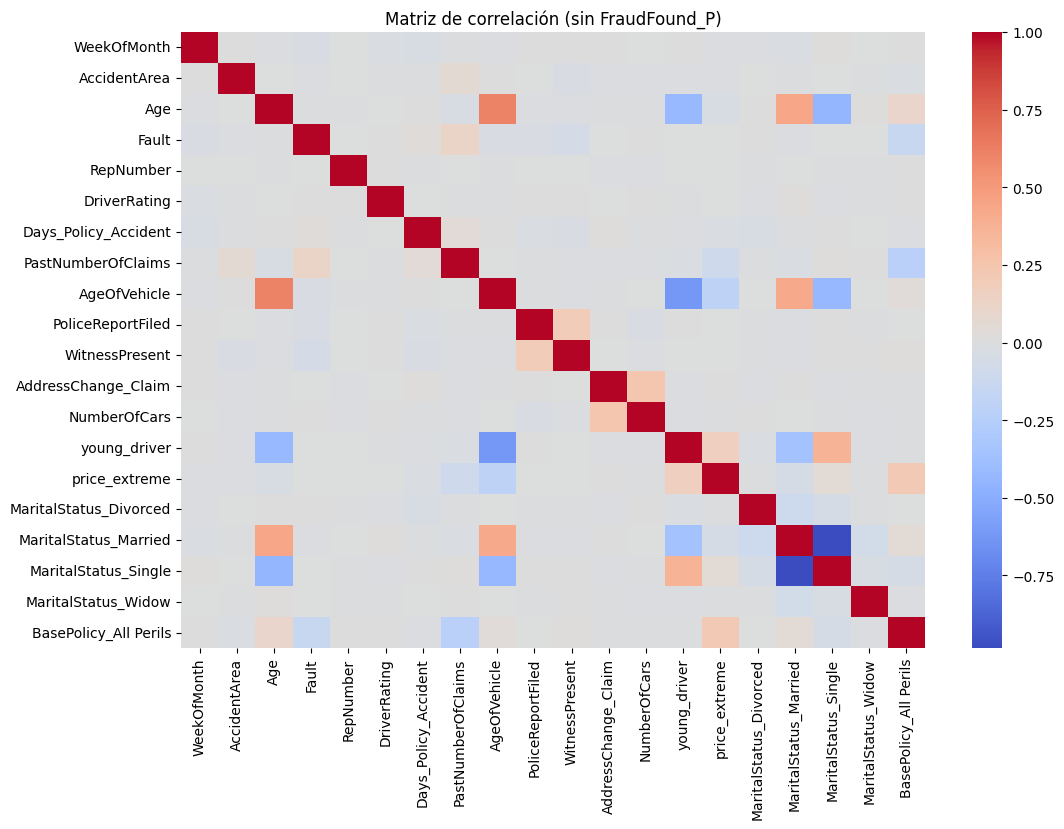

In [822]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_model.drop(columns=["FraudFound_P", 'Month_Apr', 'DayOfWeek_Friday' ,'Days_Policy_Claim', 'VehicleCategory_Sport'	, 'VehicleCategory_Sedan','VehicleCategory_Utility'	,'BasePolicy_Collision',	'BasePolicy_Liability', 'male', 'female', 'VehiclePrice','Month_Aug',	'Month_Dec',	'Month_Feb',	'Month_Jan',	'Month_Jul',	'Month_Jun'	,'Month_Mar'	,'Month_May'	,'Month_Nov',	'Month_Oct',	'Month_Sep',	'DayOfWeek_Monday'	,'DayOfWeek_Saturday'	,'DayOfWeek_Sunday'	,'DayOfWeek_Thursday'	,'DayOfWeek_Tuesday'	,'DayOfWeek_Wednesday' ]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de correlación (sin FraudFound_P)')
plt.show()

separar X y Y

In [823]:
X = df_model.drop(columns=["FraudFound_P"])
y = df_model["FraudFound_P"]

split

In [824]:
from sklearn.model_selection import train_test_split

SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

modelos de clasificacion

In [825]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [826]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=SEED
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [827]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [828]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=SEED,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

evaluacion

In [829]:
from sklearn.metrics import classification_report

def evaluar(nombre, model):
    y_pred = model.predict(X_test)
    print(f"{nombre}\n")
    print(classification_report(y_test, y_pred))
    print("="*50)

evaluar("Logistic", lr)
evaluar("Decision Tree", dt)
evaluar("Random Forest", rf)
evaluar("XGBoost", xgb)

Logistic

              precision    recall  f1-score   support

           0       0.99      0.59      0.74      2899
           1       0.12      0.91      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.61      0.71      3084

Decision Tree

              precision    recall  f1-score   support

           0       0.99      0.60      0.74      2899
           1       0.13      0.91      0.22       185

    accuracy                           0.62      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.62      0.71      3084

Random Forest

              precision    recall  f1-score   support

           0       0.99      0.63      0.77      2899
           1       0.13      0.86      0.22       185

    accuracy                           0.64      3084
   macro avg       0.56      0.74      0.50      3084
weighted avg       0.93      0.64 

overfitting

In [830]:
def overfitting(nombre, model):
    train = model.score(X_train, y_train)
    test = model.score(X_test, y_test)

    print(nombre)
    print("Train:", round(train,4))
    print("Test :", round(test,4))
    print("Gap  :", round(train - test,4))
    print()

overfitting("Logistic", lr)
overfitting("Decision Tree", dt)
overfitting("Random Forest", rf)
overfitting("XGBoost", xgb)

Logistic
Train: 0.6195
Test : 0.6112
Gap  : 0.0083

Decision Tree
Train: 0.6229
Test : 0.6154
Gap  : 0.0075

Random Forest
Train: 0.6588
Test : 0.642
Gap  : 0.0168

XGBoost
Train: 0.8375
Test : 0.7724
Gap  : 0.0652



In [831]:
import pandas as pd

pd.set_option('display.max_columns', None)

df_model.head()

,WeekOfMonth,AccidentArea,Age,Fault,VehiclePrice,FraudFound_P,RepNumber,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AddressChange_Claim,NumberOfCars,young_driver,price_extreme,male,female,Month_Apr,Month_Aug,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widow,VehicleCategory_Sedan,VehicleCategory_Sport,VehicleCategory_Utility,BasePolicy_All Perils,BasePolicy_Collision,BasePolicy_Liability
0,5,1,21,1,80000,0,12,1,4,3,0,3,0,0,1,3,1,1,0,1,False,0,1,0,0,0,0,0,0,0,0,0,False,0,0,0,0,0,1,False,0,1,0,False,1,0,False,0,1
1,3,1,34,1,80000,0,15,4,4,3,0,6,1,0,3,1,0,1,1,0,False,0,0,0,1,0,0,0,0,0,0,0,False,0,0,0,0,0,1,False,0,1,0,False,1,0,False,1,0
2,5,1,47,1,80000,0,7,3,4,3,1,7,0,0,3,1,0,1,1,0,False,0,0,0,0,0,0,0,0,0,1,0,True,0,0,0,0,0,0,False,1,0,0,False,1,0,False,1,0
3,2,0,65,0,24500,0,4,2,4,3,1,8,1,0,3,1,0,0,1,0,False,0,0,0,0,0,1,0,0,0,0,0,False,0,1,0,0,0,0,False,1,0,0,False,1,0,False,0,1
4,5,1,27,0,80000,0,3,1,4,3,0,5,0,0,3,1,0,1,0,1,False,0,0,0,1,0,0,0,0,0,0,0,False,1,0,0,0,0,0,False,0,1,0,False,1,0,False,1,0


Logistic

              precision    recall  f1-score   support

           0       0.99      0.59      0.74      2899
           1       0.12      0.91      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.61      0.71      3084



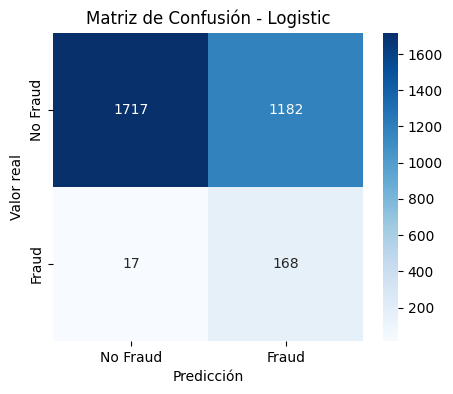

In [832]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = lr.predict(X_test)

print("Logistic\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Fraud", "Fraud"],
            yticklabels=["No Fraud", "Fraud"])
plt.title("Matriz de Confusión - Logistic")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()



Decision Tree

              precision    recall  f1-score   support

           0       0.99      0.60      0.74      2899
           1       0.13      0.91      0.22       185

    accuracy                           0.62      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.62      0.71      3084



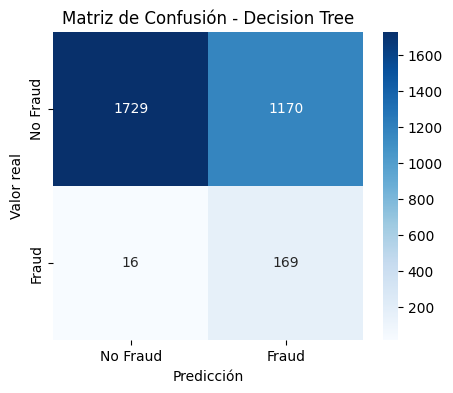

In [833]:
y_pred = dt.predict(X_test)

print("Decision Tree\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Fraud", "Fraud"],
            yticklabels=["No Fraud", "Fraud"])
plt.title("Matriz de Confusión - Decision Tree")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()



Random Forest

              precision    recall  f1-score   support

           0       0.99      0.63      0.77      2899
           1       0.13      0.86      0.22       185

    accuracy                           0.64      3084
   macro avg       0.56      0.74      0.50      3084
weighted avg       0.93      0.64      0.73      3084

XGBoost

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      2899
           1       0.14      0.57      0.23       185

    accuracy                           0.77      3084
   macro avg       0.56      0.68      0.55      3084
weighted avg       0.92      0.77      0.83      3084



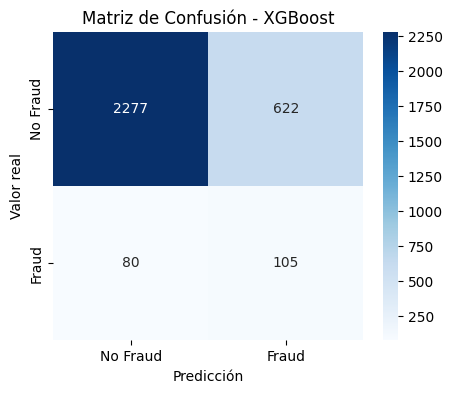

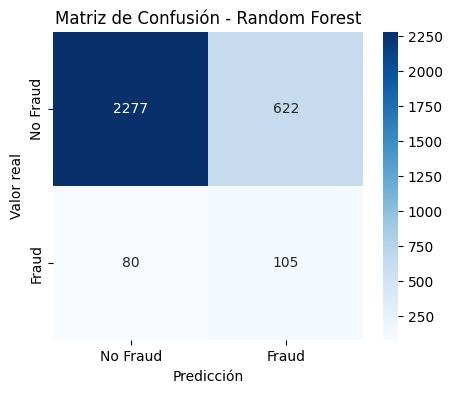

In [834]:
y_pred = rf.predict(X_test)

print("Random Forest\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
y_pred = xgb.predict(X_test)

print("XGBoost\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Fraud", "Fraud"],
            yticklabels=["No Fraud", "Fraud"])
plt.title("Matriz de Confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

print("="*50)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Fraud", "Fraud"],
            yticklabels=["No Fraud", "Fraud"])
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()



### Conclusiones basadas en la matriz de confusion

basados en las comparaciones, de cada modelo podemos concluir lo siguiente:


#### Modelo de regresion logistica

 - Tiene una tasa de fraudes no detectados muy baja 17
 - detecta 168 fraudes TP
 - los falsos positivos son demasiado altos (1182)

 interpretacion: detecta bien el fraude pero genera demasiadas falsas alarmas, el modelo es altamente sensible


 ### Decision Tree

 - tasa de fraudes no detectados muy baja, 16
 - en fraudes detectados tenemos 169
 - los falsos positivos siguen siendo altos pero un poco mejor


 interpretaciones: el mejor modelos de deteccion de fraude


 ### XGBoost

 - falsos negativos muy altos, 80
 - fraudes detectados 105
 - los falsos positivos son bastante bajos 622


 interpretacion: reduce demasiado las falsas alarmas pero deja pasar muchos fraudes, es equilibrado pero peligroso para el negocio


 ### Random Forest

 - tiene exactamente los mismos valores que XGB


 interpretacion: mismo comportamiento, no tiene gran aporte